#Download Files from Repo

In [10]:
import os


GITHUB_USER = "rah-ds"
REPO_NAME   = "Cloud-Autoscaling-using-RL"
BRANCH      = "bmcgregor/simulator-refactor"  # or "main" or another branch

# Base raw URL for GitHub
BASE_RAW_URL = f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}"

# Map of local filename -> path inside the repo

PY_FILES = {
    # Environment
    "autoscaling_env.py": "scripts/autoscaling_env.py",

    # DQN utilities and agents
    "DQN_Utils.py": "scripts/DQN_Utils.py",
    "DQN_Agent.py": "scripts/DQN_Agent.py",
    "Double_DQN_Agent.py": "scripts/Double_DQN_Agent.py",

}

print("Downloading Python files from GitHub...")
# Use a cross-platform Python downloader: try requests, fall back to urllib
try:
    import requests  # type: ignore
except Exception:
    requests = None

from urllib.request import urlopen, Request


# Directly set the download directory to /content/
DOWNLOAD_DIR = "/content/"
os.makedirs(DOWNLOAD_DIR, exist_ok=True) # Ensure the directory exists
print("Writing downloads to:", DOWNLOAD_DIR)

for local_name, repo_path in PY_FILES.items():
    url = f"{BASE_RAW_URL}/{repo_path}"
    print(f"  -> {local_name}  from  {url}")
    content = None
    if requests is not None:
        try:
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            content = resp.content
        except Exception as e:
            print(f"requests download failed: {e}; falling back to urllib")
            content = None
    if content is None:
        req = Request(url, headers={"User-Agent": "python-urllib/3"})
        try:
            with urlopen(req, timeout=30) as r:
                content = r.read()
        except Exception as e:
            print(f"Failed to download {url}: {e}")
            continue
    target_path = os.path.join(DOWNLOAD_DIR, local_name)
    try:
        with open(target_path, "wb") as f:
            f.write(content)
    except Exception as e:
        print(f"Failed to write {target_path}: {e}")

print("Done. Files in download dir:", os.listdir(DOWNLOAD_DIR))

Writing downloads to: /content/
  -> autoscaling_env.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/autoscaling_env.py
  -> DQN_Utils.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/DQN_Utils.py
  -> DQN_Agent.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/DQN_Agent.py
  -> Double_DQN_Agent.py  from  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/bmcgregor/simulator-refactor/scripts/Double_DQN_Agent.py
Done. Files in download dir: ['.config', '.ipynb_checkpoints', 'autoscaling_env.py', 'DQN_Utils.py', 'Double_DQN_Agent.py', 'DQN_Agent.py', 'sample_data']


#Setup: Imports and mount Google Drive

In [12]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# modules
from DQN_Agent import DQNAgent
from Double_DQN_Agent import DoubleDQNAgent
from DQN_Utils import evaluate_agent

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu


#Load the trained models

In [21]:
# Folder in your Google Drive where you saved the model weights
MODEL_DIR = "/content/drive/MyDrive/RL_Checkpoints/"

DQN_CHECKPOINT_PATH = os.path.join(MODEL_DIR, "dqn_checkpoint.pth")
DOUBLE_DQN_CHECKPOINT_PATH = os.path.join(MODEL_DIR, "double_dqn_checkpoint.pth")
DUELING_DQN_CHECKPOINT_PATH = os.path.join(MODEL_DIR, "dueling_dqn_checkpoint.pth")

for p in [DQN_CHECKPOINT_PATH, DOUBLE_DQN_CHECKPOINT_PATH, DUELING_DQN_CHECKPOINT_PATH]:
    print(p, "exists?", os.path.exists(p))


/content/drive/MyDrive/RL_Checkpoints/dqn_checkpoint.pth exists? True
/content/drive/MyDrive/RL_Checkpoints/double_dqn_checkpoint.pth exists? True
/content/drive/MyDrive/RL_Checkpoints/dueling_dqn_checkpoint.pth exists? True


#Define the final evaluation environment

In [23]:
import pandas as pd
from autoscaling_env import AutoScalingEnvConfig, AutoScalingEnv

# Load df_usage
df_usage = pd.read_csv('/content/drive/MyDrive/df_usage.csv')

# Final environment configuration for comparison
final_config = AutoScalingEnvConfig(
    initial_capacity=10,
    target_utilization=0.6,
    sla_threshold=0.8,
    cost_per_machine_per_minute=0.002,
    min_capacity=1,
    max_capacity=20,
    cooldown_period=5,
    demand_scale=1000.0,
    cost_weight=1.0,
    util_weight=1.0,
    sla_weight=10.0,
)

env = AutoScalingEnv(df_usage, config=final_config)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)


Observation space: Box([0. 1.], [inf 20.], (2,), float32)
Action space: Discrete(3)


#Recreate agents and load weights

In [26]:
from DQN_Agent import DQNAgent
from Double_DQN_Agent import DoubleDQNAgent

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

obs_shape = env.observation_space.shape
n_actions = env.action_space.n

# 1. Vanilla DQN
agent_dqn = DQNAgent(
    observation_space_shape=obs_shape,
    action_space_size=n_actions,
    device=device,
    seed=0
)
agent_dqn.qnetwork_local.load_state_dict(
    torch.load(DQN_CHECKPOINT_PATH, map_location=device)
)
agent_dqn.qnetwork_target.load_state_dict(agent_dqn.qnetwork_local.state_dict())
agent_dqn.qnetwork_local.to(device).eval()

# 2. Double DQN (standard network)
agent_double = DoubleDQNAgent(
    observation_space_shape=obs_shape,
    action_space_size=n_actions,
    device=device,
    seed=0
)
agent_double.qnetwork_local.load_state_dict(
    torch.load(DOUBLE_DQN_CHECKPOINT_PATH, map_location=device)
)
agent_double.qnetwork_target.load_state_dict(agent_double.qnetwork_local.state_dict())
agent_double.qnetwork_local.to(device).eval()

# 3. "Dueling Double DQN" – SAME CLASS, different trained weights
agent_dueling = DoubleDQNAgent(
    observation_space_shape=obs_shape,
    action_space_size=n_actions,
    device=device,
    seed=0
)
agent_dueling.qnetwork_local.load_state_dict(
    torch.load(DUELING_DQN_CHECKPOINT_PATH, map_location=device)
)
agent_dueling.qnetwork_target.load_state_dict(agent_dueling.qnetwork_local.state_dict())
agent_dueling.qnetwork_local.to(device).eval()

print("Loaded: DQN, Double DQN, and Dueling Double DQN (via DoubleDQNAgent).")


Using device: cpu
Loaded: DQN, Double DQN, and Dueling Double DQN (via DoubleDQNAgent).


#Evalute all three agents on the same test setting

In [27]:
num_eval_episodes = 10
max_steps_per_episode = 1000

dqn_scores, dqn_df = evaluate_agent(
    agent_dqn,
    env,
    num_eval_episodes,
    max_steps_per_episode,
    use_random_windows = True
)

double_scores, double_df = evaluate_agent(
    agent_double,
    env,
    num_eval_episodes,
    max_steps_per_episode,
    use_random_windows = True
)

dueling_scores, dueling_df = evaluate_agent(
    agent_dueling,
    env,
    num_eval_episodes,
    max_steps_per_episode,
    use_random_windows = True


)

print("Mean eval score – DQN:           ", np.mean(dqn_scores))
print("Mean eval score – Double DQN:    ", np.mean(double_scores))
print("Mean eval score – Dueling Double:", np.mean(dueling_scores))


Evaluation Episode 1	Score: -336.91
Evaluation Episode 2	Score: -346.52
Evaluation Episode 3	Score: -343.93
Evaluation Episode 4	Score: -295.25
Evaluation Episode 5	Score: -326.69
Evaluation Episode 6	Score: -338.83
Evaluation Episode 7	Score: -294.17
Evaluation Episode 8	Score: -323.42
Evaluation Episode 9	Score: -316.57
Evaluation Episode 10	Score: -316.57

Average Evaluation Score over 10 episodes: -323.89
Evaluation Episode 1	Score: -259.28
Evaluation Episode 2	Score: -259.81
Evaluation Episode 3	Score: -270.17
Evaluation Episode 4	Score: -258.51
Evaluation Episode 5	Score: -285.11
Evaluation Episode 6	Score: -287.37
Evaluation Episode 7	Score: -255.97
Evaluation Episode 8	Score: -256.74
Evaluation Episode 9	Score: -256.83
Evaluation Episode 10	Score: -277.21

Average Evaluation Score over 10 episodes: -266.70
Evaluation Episode 1	Score: -291.05
Evaluation Episode 2	Score: -256.57
Evaluation Episode 3	Score: -256.76
Evaluation Episode 4	Score: -288.11
Evaluation Episode 5	Score: -2

#Summary of Results

In [28]:
def summarize_eval(df, scores, env):
    return {
        "mean_reward": float(np.mean(scores)),
        "std_reward": float(np.std(scores)),
        "mean_capacity": float(df["current_capacity"].mean()),
        "sla_violations": int((df["utilization"] > env.sla_threshold).sum()),
    }

summary_dqn = summarize_eval(dqn_df, dqn_scores, env)
summary_double = summarize_eval(double_df, double_scores, env)
summary_dueling = summarize_eval(dueling_df, dueling_scores, env)

comparison_df = pd.DataFrame.from_dict(
    {
        "DQN": summary_dqn,
        "DoubleDQN": summary_double,
        "DuelingDoubleDQN": summary_dueling,
    },
    orient="index"
)

comparison_df


,mean_reward,std_reward,mean_capacity,sla_violations
DQN,-323.885844,17.677336,8.0063,1492
DoubleDQN,-266.700306,11.704687,10.0000,2
DuelingDoubleDQN,-272.694447,12.663777,10.0000,3


#Plot per-step reward comparison



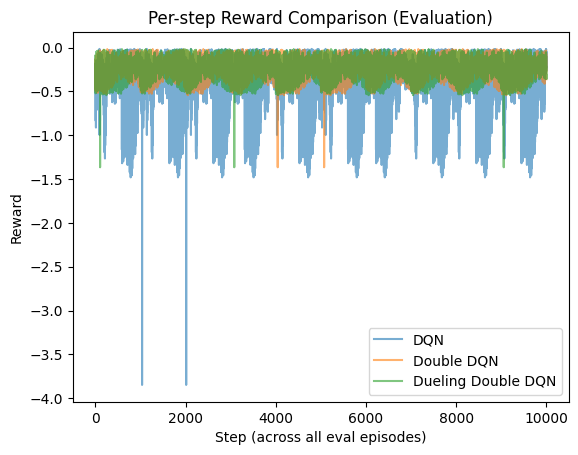

In [29]:
plt.figure()
plt.plot(dqn_df["reward"].reset_index(drop=True), label="DQN", alpha=0.6)
plt.plot(double_df["reward"].reset_index(drop=True), label="Double DQN", alpha=0.6)
plt.plot(dueling_df["reward"].reset_index(drop=True), label="Dueling Double DQN", alpha=0.6)
plt.xlabel("Step (across all eval episodes)")
plt.ylabel("Reward")
plt.title("Per-step Reward Comparison (Evaluation)")
plt.legend()
plt.show()


#Plot Capacity vs Demand for Each Model

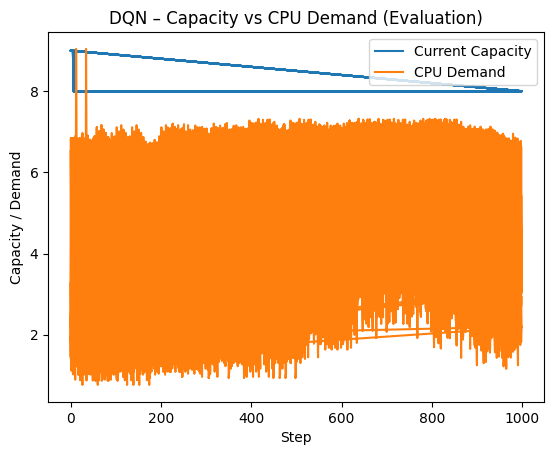

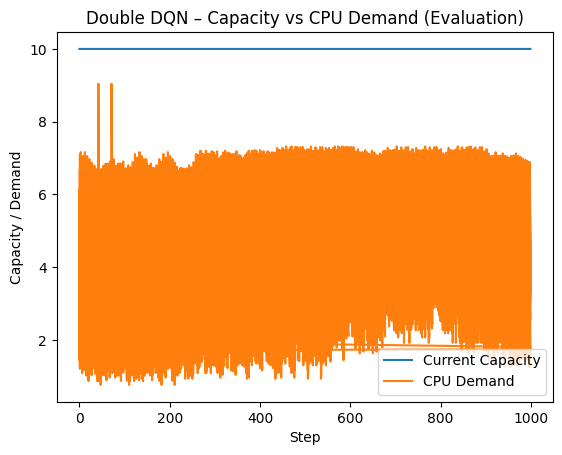

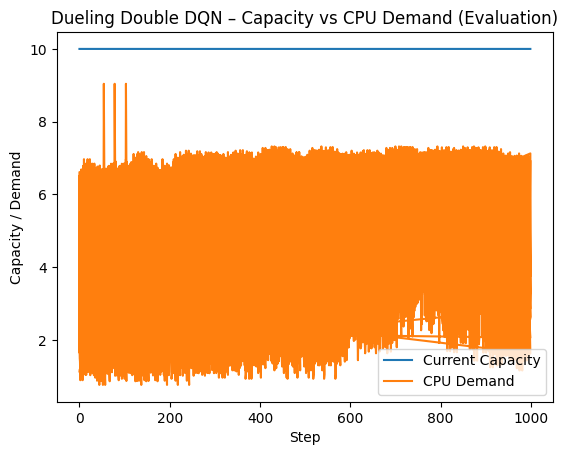

In [31]:
def plot_capacity_vs_demand(df, title):
    plt.figure()
    plt.plot(df.index, df["current_capacity"], label="Current Capacity")
    plt.plot(df.index, df["demand_cpu"], label="CPU Demand")
    plt.xlabel("Step")
    plt.ylabel("Capacity / Demand")
    plt.title(title)
    plt.legend()
    plt.show()

plot_capacity_vs_demand(dqn_df, "DQN – Capacity vs CPU Demand (Evaluation)")
plot_capacity_vs_demand(double_df, "Double DQN – Capacity vs CPU Demand (Evaluation)")
plot_capacity_vs_demand(dueling_df, "Dueling Double DQN – Capacity vs CPU Demand (Evaluation)")



#Plot Utilzation vs target/SLA for the best model

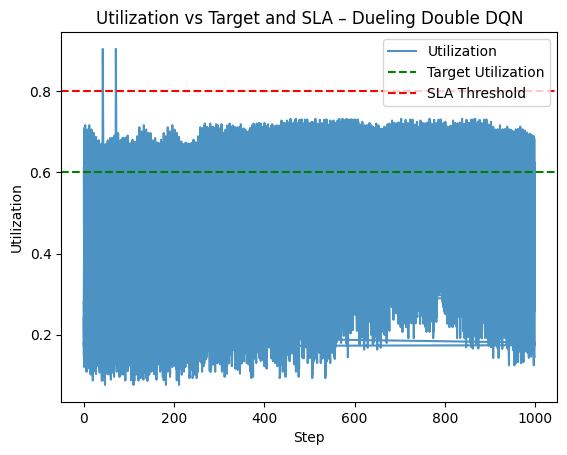

In [35]:
best_df = double_df   # change to dqn_df or double_df if you want to inspect them

plt.figure()
plt.plot(best_df.index, best_df["utilization"], label="Utilization", alpha=0.8)
plt.axhline(env.target_utilization, color="g", linestyle="--", label="Target Utilization")
plt.axhline(env.sla_threshold, color="r", linestyle="--", label="SLA Threshold")
plt.xlabel("Step")
plt.ylabel("Utilization")
plt.title("Utilization vs Target and SLA – Dueling Double DQN")
plt.legend()
plt.show()
